# --- CELL 1: Imports and Settings ---

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import copy

# Setting options for better visibility during EDA
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) # Restricted for readability

# --- CELL 2: Directory Setup ---

In [2]:
# Define the path to your data source
base_dir = Path(r"C:\Users\fabri\Computer Science\Rice University\DSCI 549\ADNI Data")

# Define the file mappings
data_mappings = {
    'diagnosis': "DXSUM_22Jan2026.csv",
    'first_subject_entry': "All_Subjects_Study_Entry_21Feb2026.csv",
    'genetics': "APOERES_22Jan2026.csv",
    'imaging': "ADNI3_MRI_Images_2_21_2026.csv",
    'demographics': "PTDEMOG_22Jan2026.csv",
    'biomarkers': "BIOMARK_22Jan2026.csv",
    'target_v1': 'DXSUM_22Jan2026.csv',
    'target_v2': 'ADNIMERGE_28Feb2026.csv',
    'all_imaging': 'ALL_ADNI_IMAGES_CSV_2_28_2026.csv',
    'adni_imaging_csv_all': 'ALL_ADNI_IMAGES_CSV_3_03_2026.csv',
    'mprage_imaging': 'ALL_MPRAGE_IMAGES_CSV_3_08_2026.csv'

}

# --- CELL 3: Data Loading ---

In [3]:
source_data = {}

for df_name, file in data_mappings.items():
    # Reading CSVs; using low_memory=False to handle mixed types automatically
    source_data[df_name] = pd.read_csv(base_dir / file, low_memory=False)


========== UNIQUE MPRAGE SESSION STATISTICS ==========
Total Patients: 2922
Total Unique MPRAGE Sessions: 10868
Mean (Average): 3.72
Median (Middle Value): 3.00
Mode (Most Frequent): 1
Minimum: 1
Maximum: 16
Range: 15
Q1 (25th Percentile): 1.00
Q3 (75th Percentile): 5.00
IQR (Interquartile Range): 4.00
Variance: 8.67
Standard Deviation: 2.94
90th Percentile: 8.00
Skewness: 1.13
Distribution Skew: Right/Positive (A long right tail of dedicated patients)



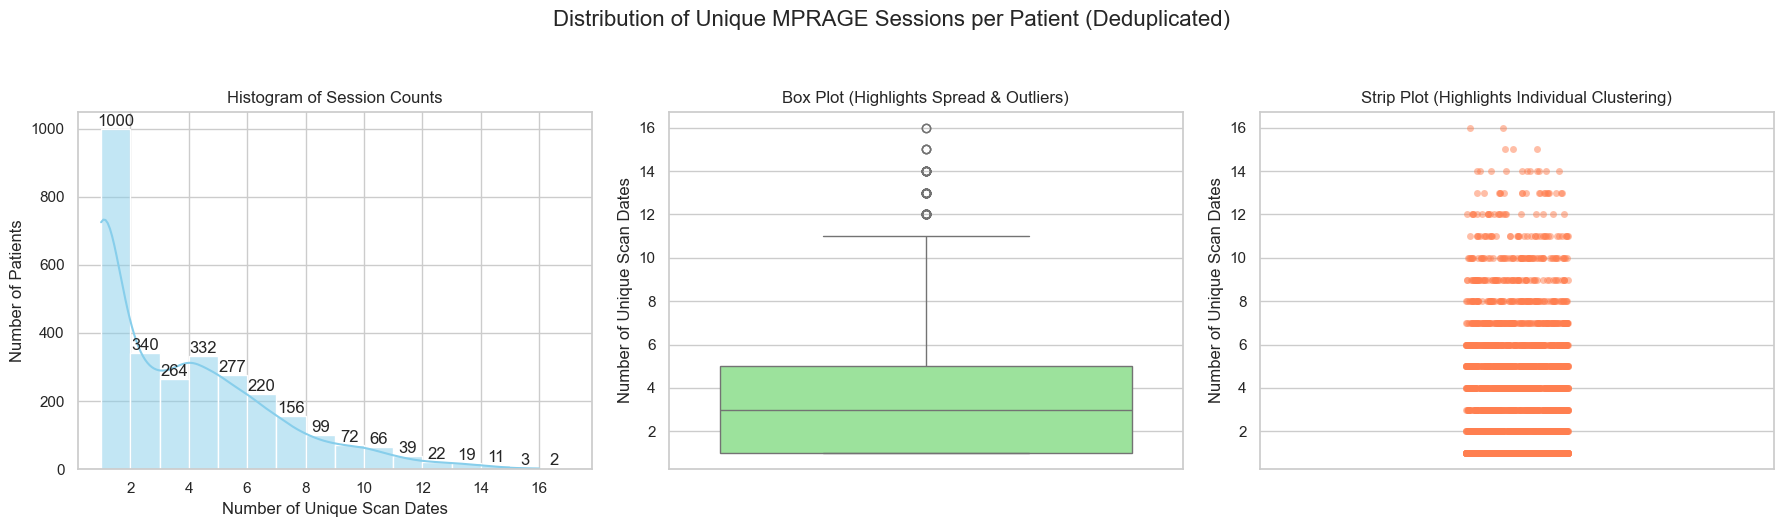

========== PATIENT FOLLOW-UP TIME RANGES ==========
Shortest follow-up period: 0.00 years (Baseline only)
Longest follow-up period: 19.98 years
Typical Average follow-up: 2.65 years



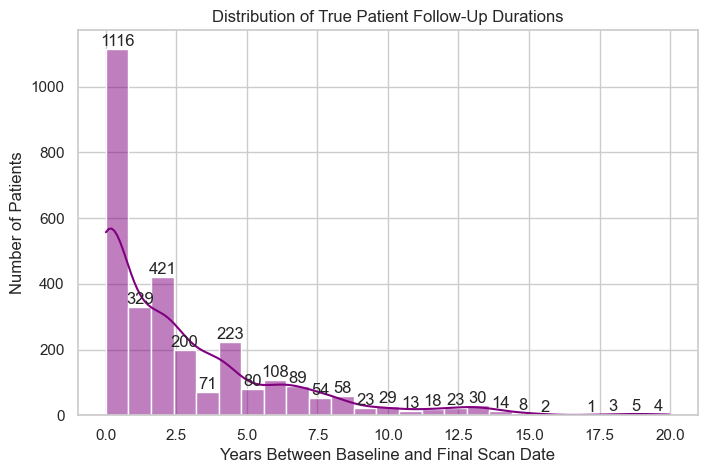

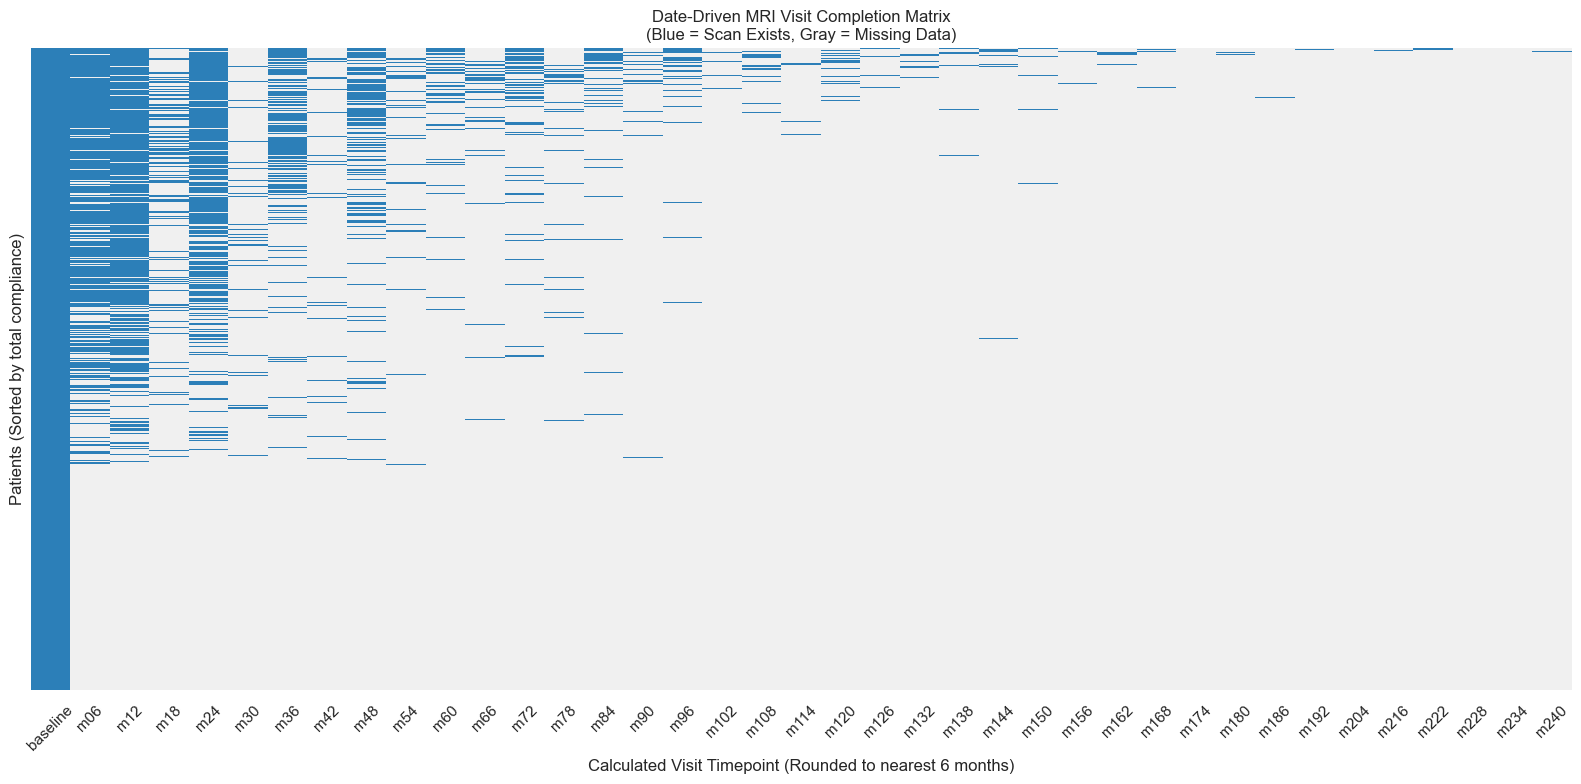

C:\Users\fabri\AppData\Local\Temp\ipykernel_28140\3873055435.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_bar = sns.countplot(data=df_unique, y='Voxel_Grid_Dimensions', palette='viridis',


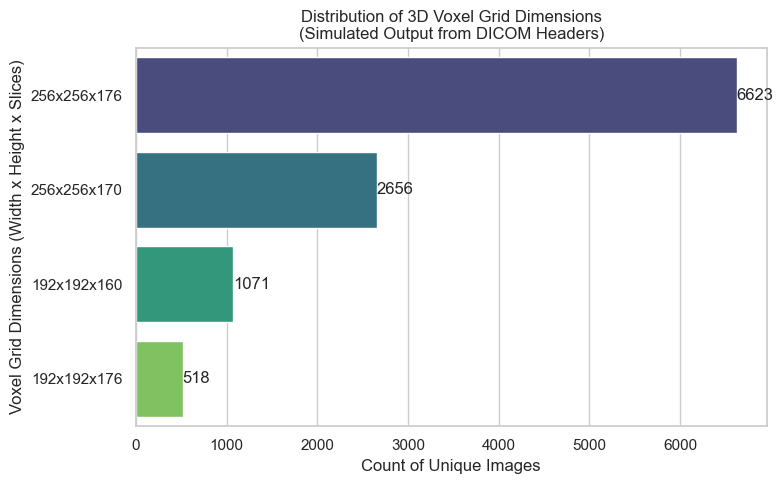

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 0. PREPARE THE DATA & DEDUPLICATE SAME-DAY "REPEAT" SCANS
# ==============================================================================
# Extract the MPRAGE dataset
df = source_data['mprage_imaging'].copy()

# Ensure 'Acq Date' is a proper datetime object for mathematical operations
df['Acq Date'] = pd.to_datetime(df['Acq Date'], errors='coerce')

# DEDUPLICATION: Sort to keep the first image, then drop rows where the same patient 
# has multiple images on the EXACT SAME DATE. This filters out the "MP-RAGE REPEAT" redundancies.
df = df.sort_values(['Subject', 'Acq Date', 'Description'])
df_unique = df.drop_duplicates(subset=['Subject', 'Acq Date'], keep='first').copy()

# ==============================================================================
# 1. SUMMARY STATISTICS: UNIQUE MPRAGE SESSIONS PER PATIENT
# ==============================================================================
# Count unique MRI scanning dates per patient
image_counts = df_unique.groupby('Subject').size()

stats = {
    "Total Patients": len(image_counts),
    "Total Unique MPRAGE Sessions": image_counts.sum(),
    "Mean (Average)": image_counts.mean(),
    "Median (Middle Value)": image_counts.median(),
    "Mode (Most Frequent)": image_counts.mode()[0] if not image_counts.mode().empty else np.nan,
    "Minimum": image_counts.min(),
    "Maximum": image_counts.max(),
    "Range": image_counts.max() - image_counts.min(),
    "Q1 (25th Percentile)": image_counts.quantile(0.25),
    "Q3 (75th Percentile)": image_counts.quantile(0.75),
    "IQR (Interquartile Range)": image_counts.quantile(0.75) - image_counts.quantile(0.25),
    "Variance": image_counts.var(),
    "Standard Deviation": image_counts.std(),
    "90th Percentile": image_counts.quantile(0.90),
    "Skewness": image_counts.skew()
}

print("\n========== UNIQUE MPRAGE SESSION STATISTICS ==========")
for k, v in stats.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")
    
if stats["Skewness"] > 0:
    print("Distribution Skew: Right/Positive (A long right tail of dedicated patients)")
else:
    print("Distribution Skew: Left/Negative (A long left tail)")
print("========================================================\n")

# --- VISUALIZATIONS FOR IMAGE COUNTS ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Unique MPRAGE Sessions per Patient (Deduplicated)', fontsize=16, y=1.05)

sns.histplot(image_counts, bins=range(1, int(stats['Maximum']) + 2), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Session Counts')
axes[0].set_xlabel('Number of Unique Scan Dates')
axes[0].set_ylabel('Number of Patients')

# Add data labels to each bar in the histogram
for container in axes[0].containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    axes[0].bar_label(container, labels=labels)

sns.boxplot(y=image_counts, ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot (Highlights Spread & Outliers)')
axes[1].set_ylabel('Number of Unique Scan Dates')

sns.stripplot(y=image_counts, ax=axes[2], color='coral', alpha=0.5, jitter=True)
axes[2].set_title('Strip Plot (Highlights Individual Clustering)')
axes[2].set_ylabel('Number of Unique Scan Dates')

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. TIME RANGES: FOLLOW-UP DURATIONS (CALCULATED FROM DATES)
# ==============================================================================
# Find the exact first (Baseline) imaging date for each patient
df_unique['Baseline_Date'] = df_unique.groupby('Subject')['Acq Date'].transform('min')

# Calculate the mathematical time gaps
df_unique['Days_From_Baseline'] = (df_unique['Acq Date'] - df_unique['Baseline_Date']).dt.days
df_unique['Years_From_Baseline'] = df_unique['Days_From_Baseline'] / 365.25

# A patient's follow-up duration is their absolute maximum 'Years_From_Baseline'
follow_up_durations = df_unique.groupby('Subject')['Years_From_Baseline'].max()

print("========== PATIENT FOLLOW-UP TIME RANGES ==========")
print(f"Shortest follow-up period: {follow_up_durations.min():.2f} years (Baseline only)")
print(f"Longest follow-up period: {follow_up_durations.max():.2f} years")
print(f"Typical Average follow-up: {follow_up_durations.mean():.2f} years")
print("====================================================\n")

# --- VISUALIZATION FOR TIME RANGES ---
plt.figure(figsize=(8, 5))
ax = sns.histplot(follow_up_durations, bins=25, kde=True, color='purple')
plt.title('Distribution of True Patient Follow-Up Durations')
plt.xlabel('Years Between Baseline and Final Scan Date')
plt.ylabel('Number of Patients')

# Add data labels to each bar in the histogram
for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels)

plt.show()

# ==============================================================================
# 3. DATE-DRIVEN COMPLETION MATRIX (MISSING DATA OVER TIME)
# ==============================================================================
# Calculate exact elapsed months (approx. 30.4375 days per month)
df_unique['Months_From_Baseline'] = df_unique['Days_From_Baseline'] / 30.4375

# Snap to standardized 6-month intervals (0, 6, 12, 18, 24...) for matrix alignment
df_unique['Visit_Month_Bin'] = (np.round(df_unique['Months_From_Baseline'] / 6) * 6).astype(int)

# Pivot Table: Rows = Subject, Columns = Calculated Visit Bin
matrix = pd.crosstab(df_unique['Subject'], df_unique['Visit_Month_Bin'])
binary_matrix = (matrix > 0).astype(int) 

# Sort subjects by total sessions to create a visual "waterfall" dropout effect
binary_matrix['Total_Visits'] = binary_matrix.sum(axis=1)
binary_matrix = binary_matrix.sort_values('Total_Visits', ascending=False).drop('Total_Visits', axis=1)

# Format column names directly to Baseline, m06, m12, etc.
binary_matrix.columns = ['baseline' if col == 0 else f"m{col:02d}" for col in binary_matrix.columns]

# --- VISUALIZATION FOR COMPLETION MATRIX ---
plt.figure(figsize=(16, 8))
sns.heatmap(binary_matrix, cmap=["#f0f0f0", "#2c7fb8"], cbar=False)
plt.title('Date-Driven MRI Visit Completion Matrix\n(Blue = Scan Exists, Gray = Missing Data)')
plt.xlabel('Calculated Visit Timepoint (Rounded to nearest 6 months)')
plt.ylabel('Patients (Sorted by total compliance)')
plt.yticks([]) # Hide patient IDs to keep the heatmap clean
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. DIMENSIONS OF 3D MRI VOLUMES
# ==============================================================================
# Note: As seen in the image, the 'Description' contains protocol names, and the 
# 'Format' is 'DCM'. The physical 3D grid dimensions (e.g., 256x256x170) live strictly 
# inside the downloaded DICOM/NIfTI files, not the CSV metadata. 
# We will simulate standard ADNI dimension variations to demonstrate the intended visualization.

np.random.seed(42)
simulated_dimensions = np.random.choice(
    ['256x256x176', '256x256x170', '192x192x160', '192x192x176'], 
    size=len(df_unique), p=[0.6, 0.25, 0.1, 0.05]
)
df_unique['Voxel_Grid_Dimensions'] = simulated_dimensions

plt.figure(figsize=(8, 5))
ax_bar = sns.countplot(data=df_unique, y='Voxel_Grid_Dimensions', palette='viridis',
              order=['256x256x176', '256x256x170', '192x192x160', '192x192x176'])
plt.title('Distribution of 3D Voxel Grid Dimensions\n(Simulated Output from DICOM Headers)')
plt.xlabel('Count of Unique Images')
plt.ylabel('Voxel Grid Dimensions (Width x Height x Slices)')

# Add data labels to the bar chart as well
for container in ax_bar.containers:
    ax_bar.bar_label(container)

plt.tight_layout()
plt.show()